# AIoT Project

In [1]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# db
import pymongo

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca

%load_ext autoreload
%autoreload 2

Start time of execution

In [2]:
time_start = time()

## Load configuration

In [3]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [4]:
client = pymongo.MongoClient(config["client"])

In [5]:
db = client[config["db"]]
coll = db[config["col"]]

In [6]:
found_keys = coll.distinct("label")
print("Existing DB keys:", found_keys)

Existing DB keys: []


## Load data

In [7]:
# Fetch all records from the collection
cursor = coll.find({})
data_list = list(cursor)

# Load into DataFrame and drop the MongoDB '_id'
df = pd.DataFrame(data_list)
if not df.empty:
    df = df.drop(columns=['_id'])
    print(f"Successfully loaded {len(df)} total instances across all subjects.")
else:
    print("No data found.")


Successfully loaded 41 total instances across all subjects.


## Explore the nature of the data

In [8]:
# Calculate the number of samples for each instance 
# We take the length of the first list inside the 'data' dictionary
df['num_samples'] = df['data'].apply(lambda x: len(next(iter(x.values()))))

# Calculate time length in seconds (samples / sampling rate)
df['time_length_sec'] = df['num_samples'] / df['sr']

# Calculate time length in minutes for easier reading
df['time_length_min'] = df['time_length_sec'] / 60

# Preview the new columns
df[['gesture_id', 'num_samples', 'time_length_sec', 'time_length_min']].head()

,gesture_id,num_samples,time_length_sec,time_length_min
0,scroll-down-thumb,9069,90.69,1.511500
1,scroll-down-thumb,9028,90.28,1.504667
2,scroll-down-thumb,6076,60.76,1.012667
3,scroll-down-thumb,4300,43.00,0.716667
4,scroll-down-thumb,6972,69.72,1.162000


In [9]:
# Group by gesture class and sum the total time length
time_per_class = df.groupby('gesture_id')['time_length_min'].sum().reset_index()
time_per_class = time_per_class.rename(columns={'time_length_min': 'total_time_min'})

# Display the aggregated data
print(time_per_class)

           gesture_id  total_time_min
0   scroll-down-thumb       14.803667
1   scroll-left-thumb       14.439500
2  scroll-right-thumb       13.953000
3     scroll-up-thumb       14.219667
4       texting-thumb       14.490000


C:\Users\gpapa\AppData\Local\Temp\ipykernel_21752\840942408.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=time_per_class, x='gesture_id', y='total_time_min', palette='viridis')


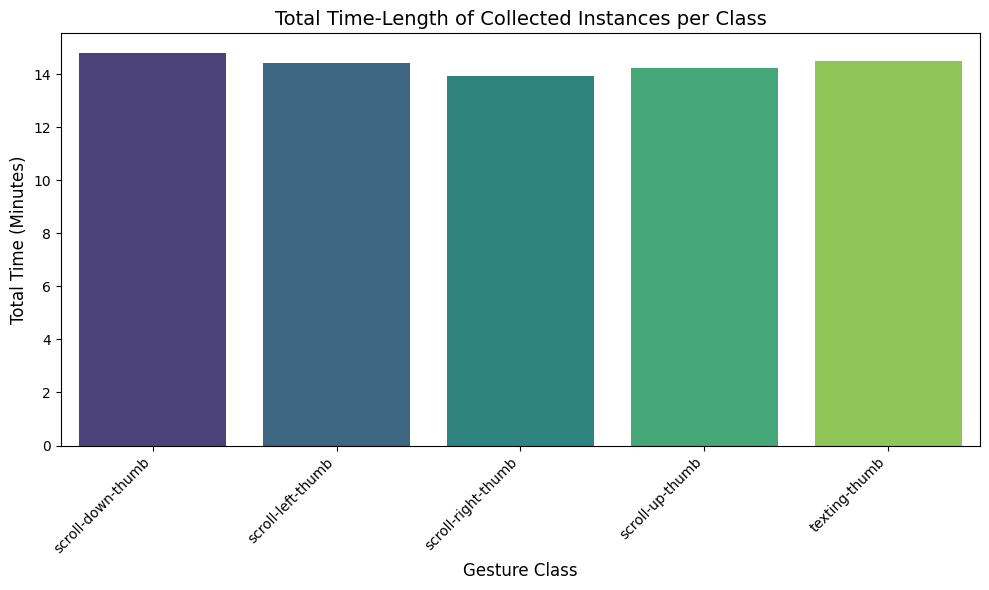

In [10]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create the barplot
sns.barplot(data=time_per_class, x='gesture_id', y='total_time_min', palette='viridis')

# Add titles and labels
plt.title('Total Time-Length of Collected Instances per Class', fontsize=14)
plt.xlabel('Gesture Class', fontsize=12)
plt.ylabel('Total Time (Minutes)', fontsize=12)

# Rotate the x-axis labels if they are long
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

In [11]:
# Check for missing values in the raw dataset before segmentation
print("Checking for missing values and unequal lengths in the raw continuous data...")
missing_found = False

for index, row in df.iterrows():
    # Convert each array to a pandas Series first. 
    # This forces Pandas to accept unequal lengths by padding the shorter ones with NaNs.
    instance_df = pd.DataFrame({k: pd.Series(v) for k, v in row['data'].items()})
    
    if instance_df.isnull().values.any():
        #print(f"Missing values or unequal lengths found in row {index} (Gesture: {row['gesture_id']}) - Fixing automatically!")
        missing_found = True
        
        # FIXING THE DATA:
        # 1. Interpolate (draw a line) to fill any internal missing packets
        instance_df = instance_df.interpolate(method='linear')
        
        # 2. Drop any remaining NaNs at the very end (truncates all arrays to the length of the shortest one)
        instance_df = instance_df.dropna()
        
        # 3. Save the cleaned data back into our main DataFrame
        df.at[index, 'data'] = instance_df.to_dict('list')

if missing_found:
    print("All missing values and unequal lengths have been successfully cleaned!")
else:
    print("No missing values found in the raw data!")

Checking for missing values and unequal lengths in the raw continuous data...
All missing values and unequal lengths have been successfully cleaned!


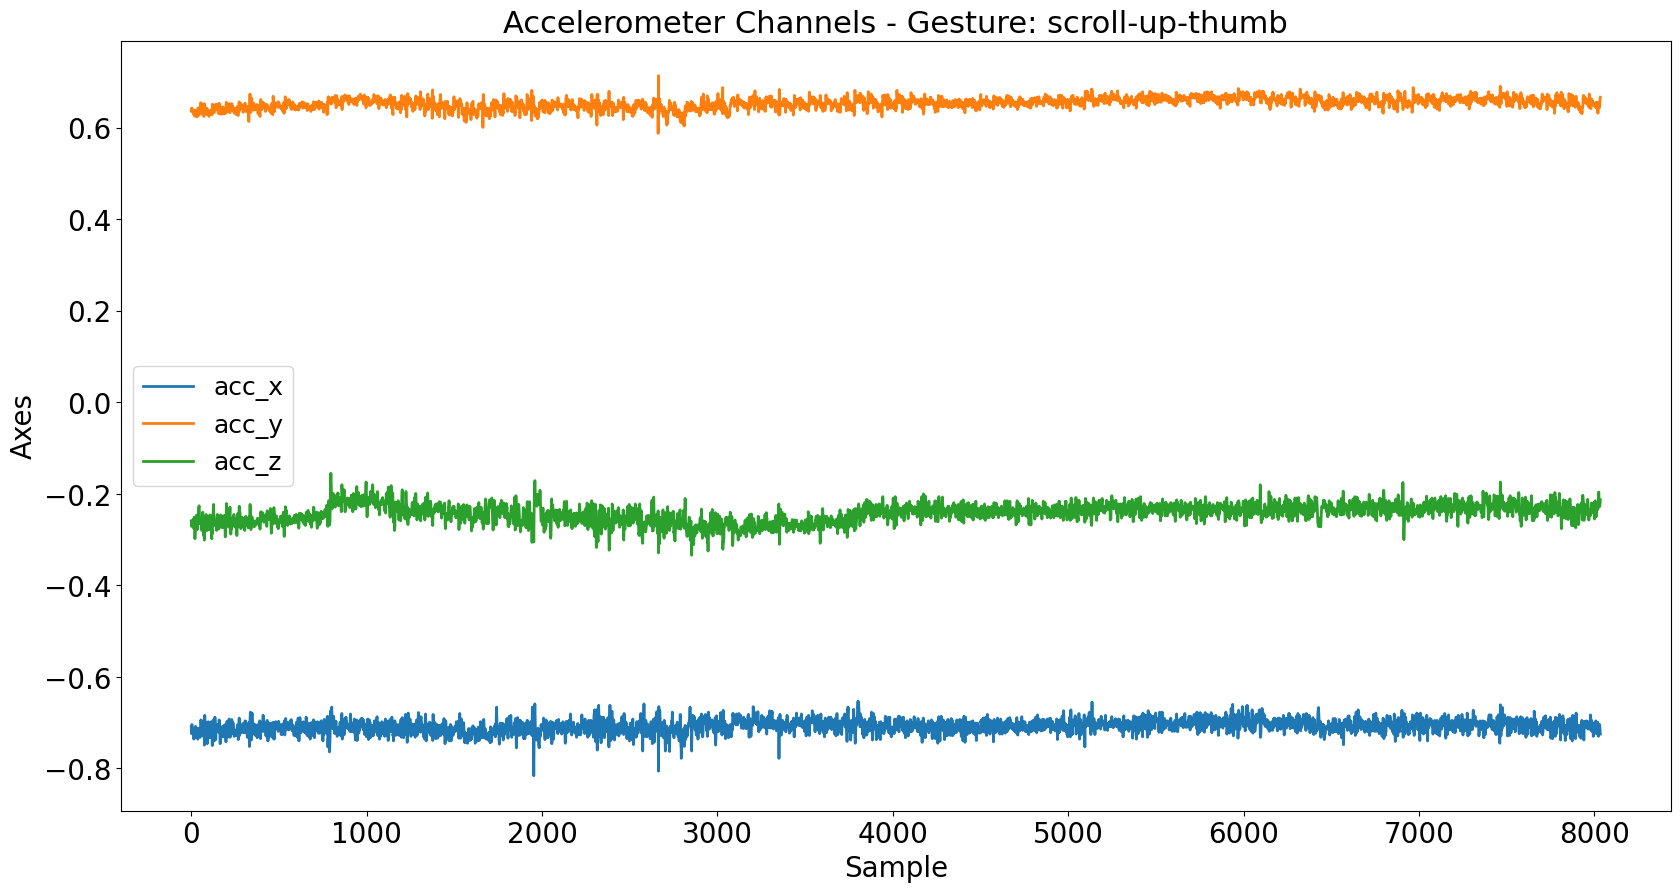

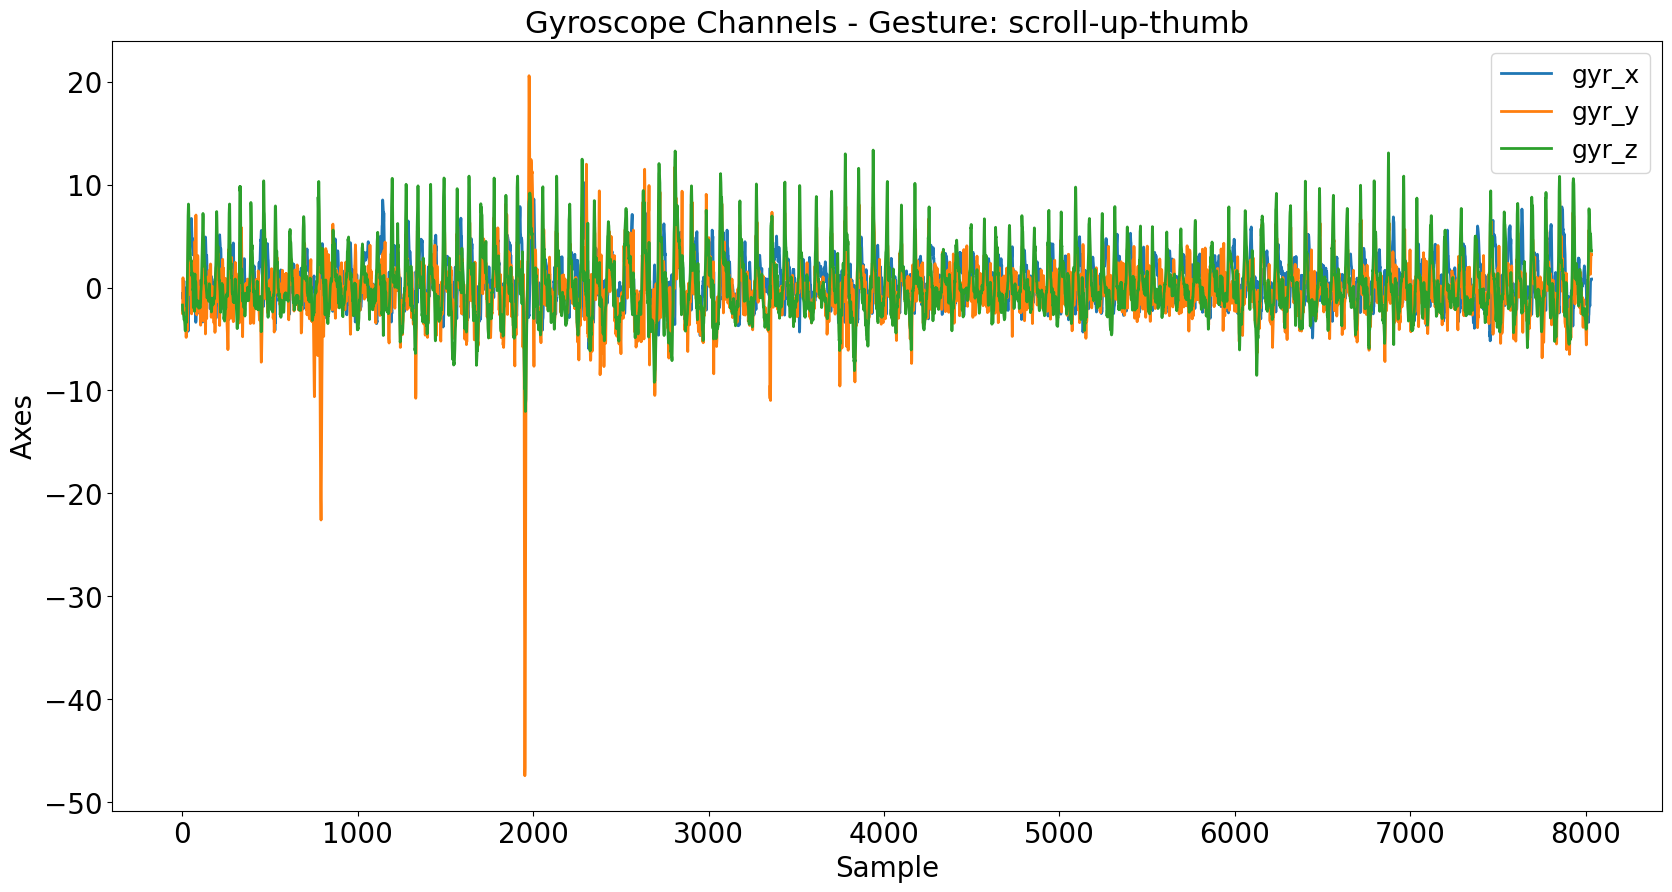

In [15]:
def plot_instance_time_domain(df: pd.DataFrame):
    """Visualizes the movement instance to a plot in time domain.

    Args:
        df: The DataFrame to be visualized in time domain.

    Returns:

    """
    df.plot(figsize=(20, 10), linewidth=2, fontsize=20).legend(fontsize=18)
    plt.xlabel('Sample', fontsize=20)
    plt.ylabel('Axes', fontsize=20)


# 1. Extract a continuous instance from the dataframe (e.g., the first recording)
sample_idx = 30
instance_df = pd.DataFrame(df.iloc[sample_idx]['data'])
gesture_id = df.iloc[sample_idx]['gesture_id'] # Get the gesture ID for the title

# 2. Separate accelerometer and gyroscope columns
acc_cols = [col for col in instance_df.columns if 'acc' in col.lower()]
gyr_cols = [col for col in instance_df.columns if 'gyr' in col.lower()]

# Fallback in case columns aren't explicitly named 'acc'/'gyr'
if not acc_cols:
    acc_cols = instance_df.columns[:3] 
if not gyr_cols:
    gyr_cols = instance_df.columns[3:6] 

# 3. Plot Accelerometer channels (Subplot 1)
plot_instance_time_domain(instance_df[acc_cols])
plt.title(f'Accelerometer Channels - Gesture: {gesture_id}', fontsize=22)
plt.show()

# 4. Plot Gyroscope channels (Subplot 2)
plot_instance_time_domain(instance_df[gyr_cols])
plt.title(f'Gyroscope Channels - Gesture: {gesture_id}', fontsize=22)
plt.show()

In [19]:
# 1. Extract sliding window parameters from your config
ws = config['sliding_window']['ws']
overlap = config['sliding_window']['overlap']
w_type = config['sliding_window']['w_type']
w_center = config['sliding_window']['w_center']

# 2. Initialize lists to hold the new windowed data and their labels
segmented_windows = []
window_labels = []

# 3. Iterate over each cleaned recording in your dataset
print("Segmenting data into fixed windows...")
for index, row in df.iterrows():
    # Convert the now perfectly-aligned dictionary into a DataFrame
    instance_df = pd.DataFrame(row['data'])
    
    # Apply the sliding window function from utils.py
    # This returns a list of smaller DataFrames (the windows)
    windows_list = sliding_window_pd(
        df=instance_df, 
        ws=ws, 
        overlap=overlap, 
        w_type=w_type, 
        w_center=w_center, 
        print_stats=False  # Set to True if you want detailed printouts for each window
    )
    
    # Store the resulting windows and attach the correct gesture label to each
    for w in windows_list:
        segmented_windows.append(w)
        window_labels.append(row['gesture_id'])

print(f"Successfully generated {len(segmented_windows)} segmented windows in total.")

Segmenting data into fixed windows...
Successfully generated 7129 segmented windows in total.


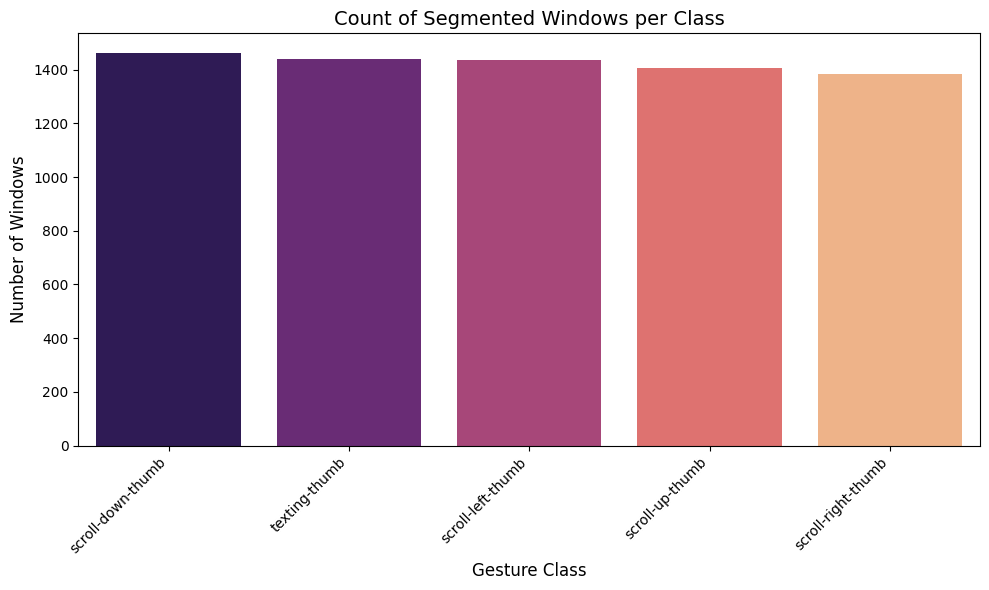

In [20]:
# Create a DataFrame to easily count the labels
window_counts_df = pd.DataFrame({'gesture_id': window_labels})
counts_per_class = window_counts_df['gesture_id'].value_counts().reset_index()
counts_per_class.columns = ['gesture_id', 'window_count']

# Set the figure size
plt.figure(figsize=(10, 6))

# Create the barplot
# (Using hue and legend=False to avoid the seaborn warning you got earlier)
sns.barplot(data=counts_per_class, x='gesture_id', y='window_count', hue='gesture_id', palette='magma', legend=False)

# Add titles and labels
plt.title('Count of Segmented Windows per Class', fontsize=14)
plt.xlabel('Gesture Class', fontsize=12)
plt.ylabel('Number of Windows', fontsize=12)

# Rotate the x-axis labels if they are long
plt.xticks(rotation=45, ha='right')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [21]:
# 1. Extract filter parameters from your config
filter_order = config['filter']['order']
wn_raw = config['filter']['wn']  # This is 10 Hz
filter_type = config['filter']['type']

# Calculate the normalized frequency for SciPy
# Nyquist frequency is half the sampling rate (100Hz / 2 = 50Hz)
nyquist_freq = 100 / 2
wn_normalized = wn_raw / nyquist_freq  # This becomes 0.2

# 2. Apply the filter to your list of chopped windows
print(f"Applying {filter_type} filter (Order: {filter_order}, Raw Freq: {wn_raw}Hz, Normalized: {wn_normalized})...")
filtered_windows = filter_instances(
    instances_list=segmented_windows, 
    order=filter_order, 
    wn=wn_normalized, 
    filter_type=filter_type
)

print(f"Successfully filtered {len(filtered_windows)} windows.")

Applying lowpass filter (Order: 4, Raw Freq: 10Hz, Normalized: 0.2)...
Number of filtered instances in the list: 7129
Successfully filtered 7129 windows.


## Data Processing

## Train/Test split

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=42)

## Scaling

In [18]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Classifier - Statistical Learning

### Apply simple classifier

In [19]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

### Evaluate simple classifier

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [21]:
from sklearn.metrics import classification_report

### Apply optimization with Grid Search and/or Cross-validation

In [22]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

### Evaluate optimized classifier